In [1]:
# ── Librerías ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import janitor
import sqlalchemy as sa
import os
from pathlib import Path
from dotenv import load_dotenv

%matplotlib inline

# ── Opciones de visualización ─────────────────────────────────────────
# Desactivar notación científica
pd.set_option('display.float_format', '{:.3f}'.format)
np.set_printoptions(suppress=True)

# Ver todas las columnas al imprimir un DataFrame
pd.set_option('display.max_columns', None)

# ── Rutas del proyecto ────────────────────────────────────────────────
# Se resuelven desde la ubicación del notebook, así funcionan
# igual en cualquier máquina
RAIZ = Path.cwd().parent

ORIGINALES   = RAIZ / '02_datos' / '01_Originales'
VALIDACION   = RAIZ / '02_datos' / '02_Validacion'
ENTRENAMIENTO = RAIZ / '02_datos' / '03_Entrenamiento'
CACHES       = RAIZ / '02_datos' / '04_Caches'
MODELOS      = RAIZ / '05_modelos'
RESULTADOS   = RAIZ / '06_resultados'

# ── Variables de entorno ──────────────────────────────────────────────
load_dotenv(RAIZ / '.env')

print('✅ Entorno listo')
print(f'   Raíz del proyecto: {RAIZ}')

✅ Entorno listo
   Raíz del proyecto: c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes


In [2]:
# ── Carga del tablón de entrenamiento actual ─────────────────────────
# Fuente: copilot-instructions.md → 02_train_tablon_calidad.pkl
df = pd.read_pickle(ENTRENAMIENTO / '02_train_tablon_calidad.pkl')

print(f'✅ Tablón cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.shape, df.dtypes.head()

✅ Tablón cargado: 28015 filas × 16 columnas


((28015, 16),
 edad               int64
 trabajo         category
 estado_civil    category
 formacion       category
 impago          category
 dtype: object)

In [3]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 1 — Carga del tablón y tipificación de variables
# ═══════════════════════════════════════════════════════════════════════

# ── Parámetros de EDA ─────────────────────────────────────────────────
params = {
    'umbral_alta_cardinalidad': None,           # None → heurística (5% filas, min 20)
    'umbral_rare_labels': None,                 # None → heurística (0.5% filas)
    'umbral_missing_alerta': 0.05,              # 5% de missing → alerta
    'max_variables_por_bloque_graficos': 6,     # variables por bloque gráfico
    'max_top_categorias_alta_cardinalidad': 20, # top categorías (alta cardinalidad)
    'max_categorias_grafico': None,             # None → mostrar todas
}

# ── 1. Confirmación de la carga ────────────────────────────────────────
print('── 1. CONFIRMACIÓN DE CARGA ──')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print()
df.head()

# ── 2. Tipificación de variables ──────────────────────────────────────
print('── 2. TIPIFICACIÓN DE VARIABLES ──')
print()

# Heurística de alta cardinalidad si params es None
umbral_ac = params['umbral_alta_cardinalidad']
if umbral_ac is None:
    umbral_ac = max(20, int(0.05 * len(df)))

tipos = {'numericas_discretas': [], 'numericas_continuas': [],
         'categoricas': [], 'alta_cardinalidad': []}

for col in df.columns:
    dtype = df[col].dtype
    nunique = df[col].nunique(dropna=True)
    if pd.api.types.is_numeric_dtype(dtype):
        if pd.api.types.is_integer_dtype(dtype) and nunique <= min(20, int(0.05 * len(df))):
            tipos['numericas_discretas'].append(col)
        else:
            tipos['numericas_continuas'].append(col)
    else:
        if nunique > umbral_ac:
            tipos['alta_cardinalidad'].append(col)
        else:
            tipos['categoricas'].append(col)

for tipo, cols in tipos.items():
    print(f'• {tipo} ({len(cols)}): {cols}')

# ── 3. Resumen por tipo de variable ───────────────────────────────────
print()
print('── 3. RESUMEN POR TIPO DE VARIABLE ──')
resumen_tipos = pd.DataFrame({
    'Tipo': list(tipos.keys()),
    'Nº columnas': [len(v) for v in tipos.values()],
})
print(resumen_tipos.to_string(index=False))

# ── 4. Detección preliminar: constantes, missing y cardinalidad ───────
print()
print('── 4. DETECCIÓN PRELIMINAR ──')
print()

# Columnas constantes
constantes = []
for c in df.columns:
    if df[c].nunique(dropna=True) <= 1:
        constantes.append(c)
print(f'• Columnas constantes ({len(constantes)}):',
      constantes if constantes else 'ninguna')
print()

# Columnas con missing (en %)
missing_info = df.isna().mean() * 100
columnas_con_missing = missing_info[missing_info > 0]
print('• Columnas con valores ausentes:')
if columnas_con_missing.empty:
    print('  Ninguna columna tiene valores ausentes')
else:
    tmp_missing = pd.DataFrame({'columna': columnas_con_missing.index,
                                '% missing': columnas_con_missing.values})
    tmp_missing = tmp_missing.sort_values('% missing', ascending=False)
    tmp_missing['% missing'] = tmp_missing['% missing'].round(2)
    print(tmp_missing.to_string(index=False))
    print()
    umbral_pct = params['umbral_missing_alerta'] * 100
    sobre_umbral = columnas_con_missing[columnas_con_missing > umbral_pct]
    if not sobre_umbral.empty:
        print(f'  ⚠️ Superan umbral de alerta ({umbral_pct:.0f}%): {list(sobre_umbral.index)}')
    else:
        print(f'  Ninguna supera el umbral de alerta ({umbral_pct:.0f}%)')
print()

# Cardinalidad de todas las columnas
print('• Cardinalidad (valores distintos por columna):')
card = pd.DataFrame({'columna': df.columns,
                     'nunique': [df[c].nunique(dropna=True) for c in df.columns]})
print(card.sort_values('nunique', ascending=False).to_string(index=False))

── 1. CONFIRMACIÓN DE CARGA ──
Dimensiones: 28015 filas × 16 columnas

── 2. TIPIFICACIÓN DE VARIABLES ──

• numericas_discretas (3): ['num_contactos_otras_campanas', 'variacion_tasa_empleo', 'contrata_fondos']
• numericas_continuas (4): ['edad', 'num_contactos_esta_campana', 'num_dias_ultimo_contacto', 'euribor3m']
• categoricas (9): ['trabajo', 'estado_civil', 'formacion', 'impago', 'prestamo_hipotecario', 'prestamo_personal', 'canal_de_contacto', 'mes', 'resultado_campana_anterior']
• alta_cardinalidad (0): []

── 3. RESUMEN POR TIPO DE VARIABLE ──
               Tipo  Nº columnas
numericas_discretas            3
numericas_continuas            4
        categoricas            9
  alta_cardinalidad            0

── 4. DETECCIÓN PRELIMINAR ──

• Columnas constantes (0): ninguna

• Columnas con valores ausentes:
  Ninguna columna tiene valores ausentes

• Cardinalidad (valores distintos por columna):
                     columna  nunique
                   euribor3m      311
          

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 2 — EDA numéricas (análisis estadístico)
# ═══════════════════════════════════════════════════════════════════════

# ── Función de estadísticos extendidos (industrializable) ─────────────
def estadisticos_numericos(df, cols):
    """Estadísticos extendidos para columnas numéricas.
    - describe() ampliado con percentiles 1, 5, 25, 50, 75, 95, 99
    - % missing, sesgo, curtosis y outliers por IQR
    """
    filas = []
    for col in cols:
        serie = df[col]
        q = serie.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
        q1, q3 = q.loc[0.25], q.loc[0.75]
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((serie < lim_inf) | (serie > lim_sup)).sum())
        filas.append({
            'columna': col,
            'n': len(serie),
            'missing': int(serie.isna().sum()),
            '% missing': serie.isna().mean() * 100,
            'media': serie.mean(),
            'desv': serie.std(),
            'min': serie.min(),
            'p1': q.loc[0.01],
            'p5': q.loc[0.05],
            'p25': q.loc[0.25],
            'p50': q.loc[0.50],
            'p75': q.loc[0.75],
            'p95': q.loc[0.95],
            'p99': q.loc[0.99],
            'max': serie.max(),
            'sesgo': serie.skew(),
            'curtosis': serie.kurtosis(),
            'n_outliers_IQR': n_out,
            '% outliers_IQR': n_out / len(serie) * 100,
        })
    return pd.DataFrame(filas)

# ── Numéricas discretas ───────────────────────────────────────────────
disc = tipos['numericas_discretas']
print('═' * 70)
print('NUMÉRICAS DISCRETAS')
print('═' * 70)
print(f'Variables ({len(disc)}): {disc}')
print()
if disc:
    tabla_disc = estadisticos_numericos(df, disc)
    print(tabla_disc.round(3).to_string(index=False))
else:
    print('(no hay variables de este tipo)')
print()

# ── Numéricas continuas ───────────────────────────────────────────────
cont = tipos['numericas_continuas']
print('═' * 70)
print('NUMÉRICAS CONTINUAS')
print('═' * 70)
print(f'Variables ({len(cont)}): {cont}')
print()
if cont:
    tabla_cont = estadisticos_numericos(df, cont)
    print(tabla_cont.round(3).to_string(index=False))
else:
    print('(no hay variables de este tipo)')

══════════════════════════════════════════════════════════════════════
NUMÉRICAS DISCRETAS
══════════════════════════════════════════════════════════════════════
Variables (3): ['num_contactos_otras_campanas', 'variacion_tasa_empleo', 'contrata_fondos']

                     columna     n  missing  % missing  media   desv  min      p1      p5     p25    p50    p75    p95    p99  max  sesgo  curtosis  n_outliers_IQR  % outliers_IQR
num_contactos_otras_campanas 28015        0      0.000  0.179  0.505    0   0.000   0.000   0.000  0.000  0.000  1.000  2.000    7  3.771    19.217            3929          14.025
       variacion_tasa_empleo 28015        0      0.000  0.745 15.673  -34 -34.000 -29.000 -18.000 11.000 14.000 14.000 14.000   14 -0.712    -1.070               0           0.000
             contrata_fondos 28015        0      0.000  0.115  0.320    0   0.000   0.000   0.000  0.000  0.000  1.000  1.000    1  2.407     3.794            3234          11.544

════════════════════════

══════════════════════════════════════════════════════════════════════
NUMÉRICAS DISCRETAS — GRÁFICOS DE BARRAS
══════════════════════════════════════════════════════════════════════


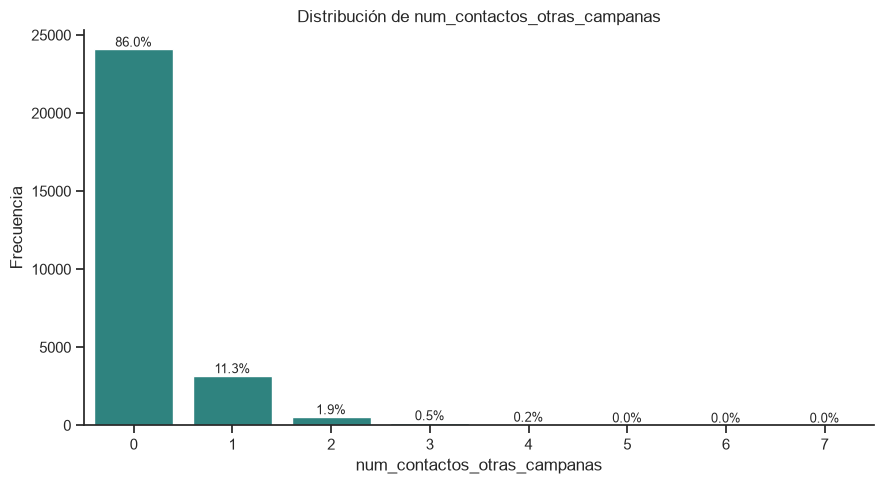

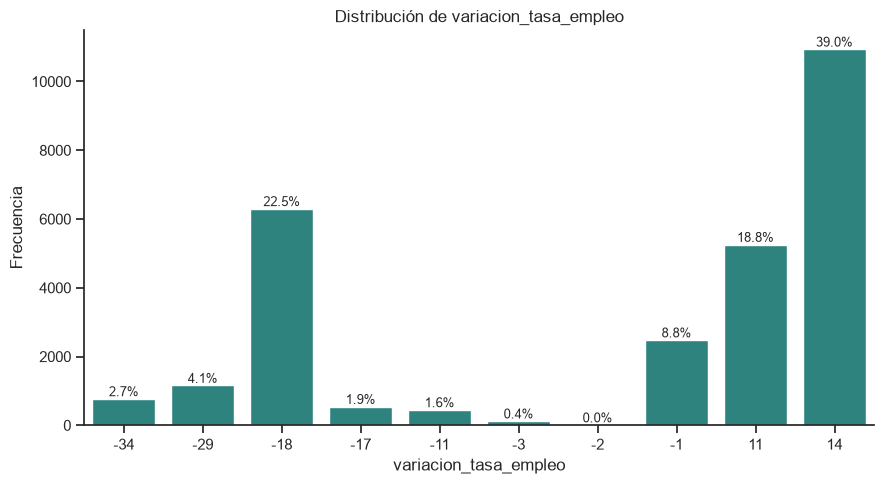

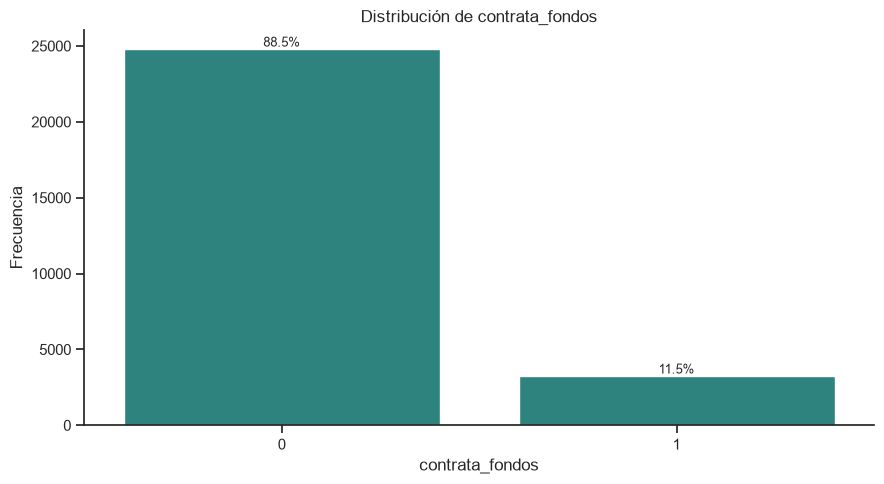

══════════════════════════════════════════════════════════════════════
NUMÉRICAS CONTINUAS — GRÁFICOS KDE
══════════════════════════════════════════════════════════════════════


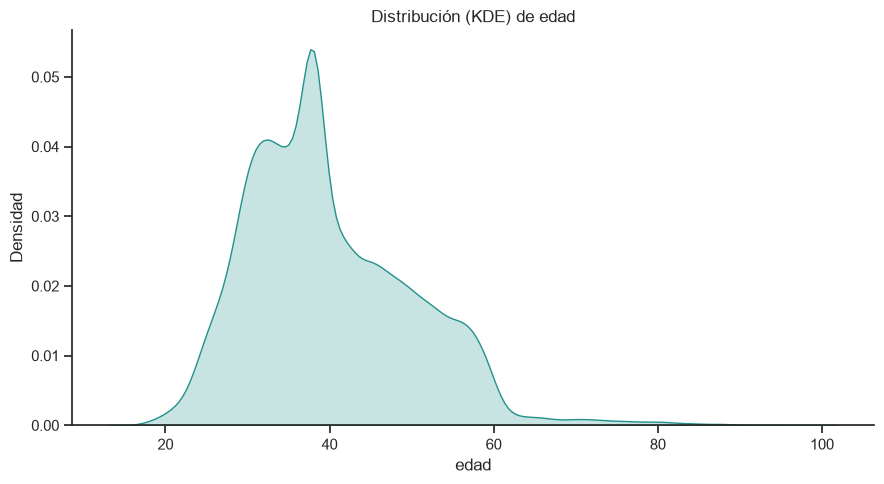

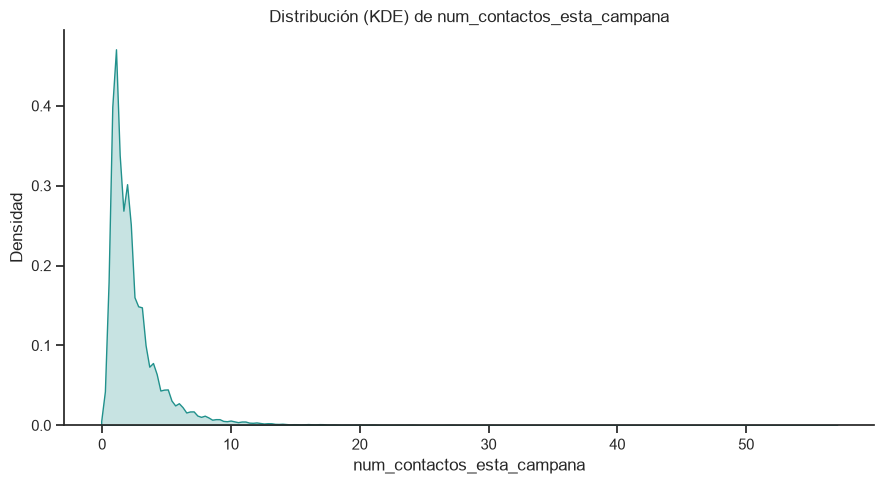

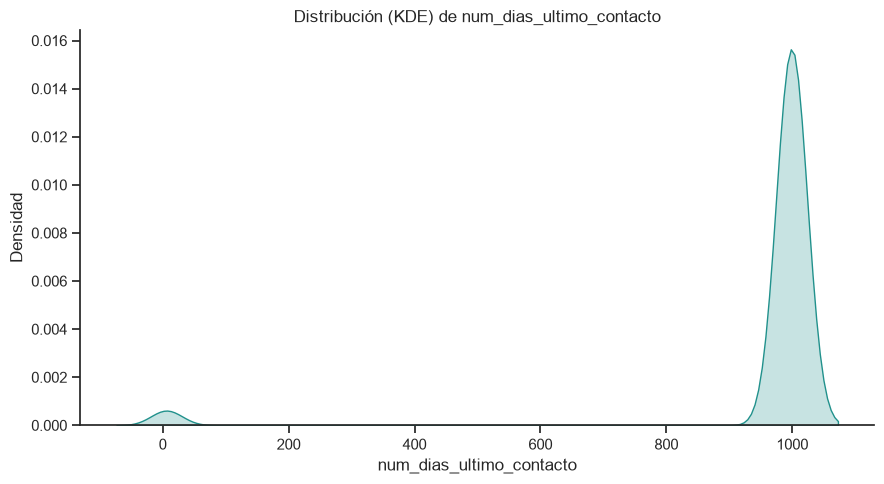

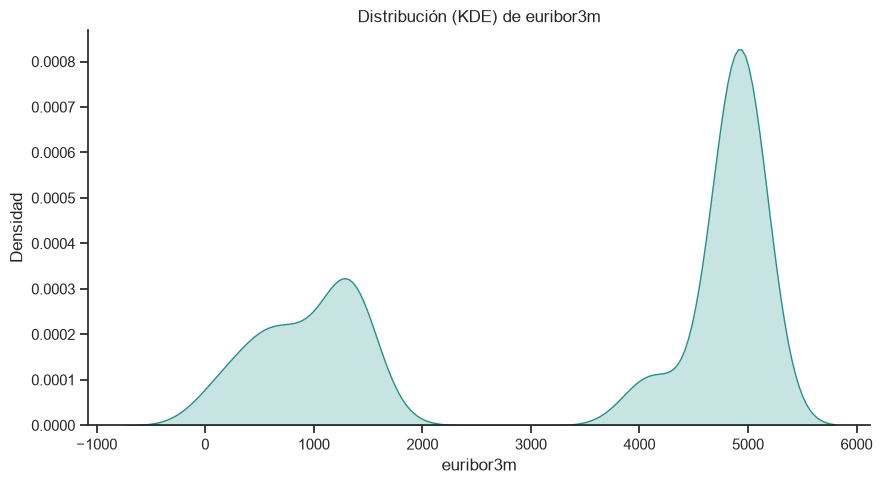

✅ Gráficos generados


In [5]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 3 — EDA numéricas (análisis gráfico)
# ═══════════════════════════════════════════════════════════════════════

# ── Tema profesional seaborn ──────────────────────────────────────────
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

color_eda = sns.color_palette("viridis", 1)[0]

# ── Variables objetivo de esta tarea (tipificación de la Tarea 1) ─────
disc = tipos['numericas_discretas']
cont = tipos['numericas_continuas']

# ── Función: barras para numéricas discretas (con % sobre total) ──────
def grafico_barras_discreta(df, col):
    conteo = df[col].value_counts(dropna=True).sort_index()
    total = conteo.sum()
    pct = conteo / total * 100

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=conteo.index.astype(str), y=conteo.values,
                     color=color_eda)
    for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
        ax.text(i, v, f'{p:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

# ── Función: KDE para numéricas continuas ─────────────────────────────
def grafico_kde(df, col):
    plt.figure(figsize=(9, 5))
    sns.kdeplot(data=df, x=col, fill=True, color=color_eda)
    ax = plt.gca()
    ax.set_title(f'Distribución (KDE) de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    plt.tight_layout()
    plt.show()

# ── Bloque 1: numéricas discretas (barras) ────────────────────────────
print('═' * 70)
print('NUMÉRICAS DISCRETAS — GRÁFICOS DE BARRAS')
print('═' * 70)
for col in disc:
    grafico_barras_discreta(df, col)

# ── Bloque 2: numéricas continuas (KDE) ───────────────────────────────
print('═' * 70)
print('NUMÉRICAS CONTINUAS — GRÁFICOS KDE')
print('═' * 70)
for col in cont:
    grafico_kde(df, col)

print('✅ Gráficos generados')

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 4 — EDA categóricas y booleanas (análisis estadístico)
# ═══════════════════════════════════════════════════════════════════════

cat = tipos['categoricas']

# Heurística de rare labels si params es None (0.5% de las filas)
umbral_rare = params['umbral_rare_labels']
if umbral_rare is None:
    umbral_rare = 0.005

# ── Resumen por variable categórica ────────────────────────────────────
def estadisticos_categoricas(df, cols, umbral_rare):
    filas = []
    for col in cols:
        serie = df[col]
        vc = serie.value_counts(dropna=False)
        n = len(serie)
        n_missing = int(serie.isna().sum())
        n_cat = serie.nunique(dropna=True)
        dominante = vc.index[0] if len(vc) > 0 else None
        pct_dominante = vc.iloc[0] / n * 100 if len(vc) > 0 else 0
        n_rare = int((vc / n < umbral_rare).sum())
        filas.append({
            'columna': col,
            'cardinalidad': n_cat,
            'missing': n_missing,
            '% missing': n_missing / n * 100,
            'categoria_dominante': dominante,
            '% dominante': pct_dominante,
            'n_rare_labels': n_rare,
        })
    return pd.DataFrame(filas)

tabla_cat = estadisticos_categoricas(df, cat, umbral_rare)
print('═══ CATEGÓRICAS / BOOLEANAS — RESUMEN ═══')
print(f'Umbral rare labels: {umbral_rare*100:.2f}% de las filas '
      f'({int(umbral_rare*len(df))} observaciones)')
print()
print(tabla_cat.round(2).to_string(index=False))
print()

# ── Distinción categóricas normales vs. alta cardinalidad ─────────────
print(f'• Alta cardinalidad (umbral > {umbral_ac}):',
      tipos['alta_cardinalidad'] if tipos['alta_cardinalidad'] else 'ninguna')

# ── Frecuencias detalladas por variable ───────────────────────────────
print()
print('═══ FRECUENCIAS DETALLADAS POR VARIABLE ═══')
print()
for col in cat:
    print('─' * 60)
    print(f'Variable: {col}')
    print('─' * 60)
    vc = df[col].value_counts(dropna=True).sort_values(ascending=False)
    total = vc.sum()
    freq = pd.DataFrame({
        'categoria': vc.index,
        'frecuencia': vc.values,
        '%': (vc.values / total * 100).round(2),
    })
    print(freq.to_string(index=False))
    print()

═══ CATEGÓRICAS / BOOLEANAS — RESUMEN ═══
Umbral rare labels: 0.50% de las filas (140 observaciones)

                   columna  cardinalidad  missing  % missing categoria_dominante  % dominante  n_rare_labels
                   trabajo            12        0      0.000              admin.       25.080              0
              estado_civil             4        0      0.000             married       60.780              1
                 formacion             8        0      0.000   university.degree       25.550              1
                    impago             3        0      0.000                  no       79.030              1
      prestamo_hipotecario             3        0      0.000                 yes       52.170              0
         prestamo_personal             3        0      0.000                  no       82.130              0
         canal_de_contacto             2        0      0.000            cellular       62.990              0
                       mes

══════════════════════════════════════════════════════════════════════
CATEGÓRICAS / BOOLEANAS — GRÁFICOS DE BARRAS
══════════════════════════════════════════════════════════════════════


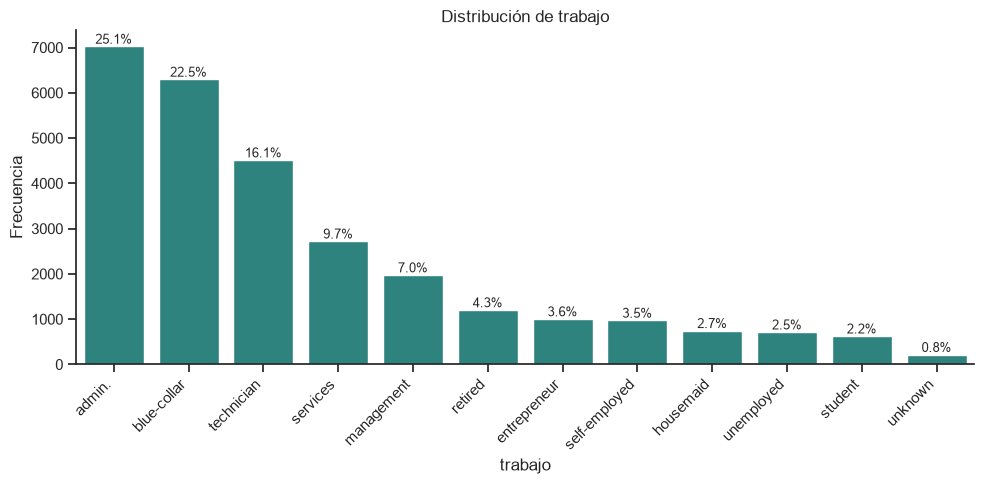

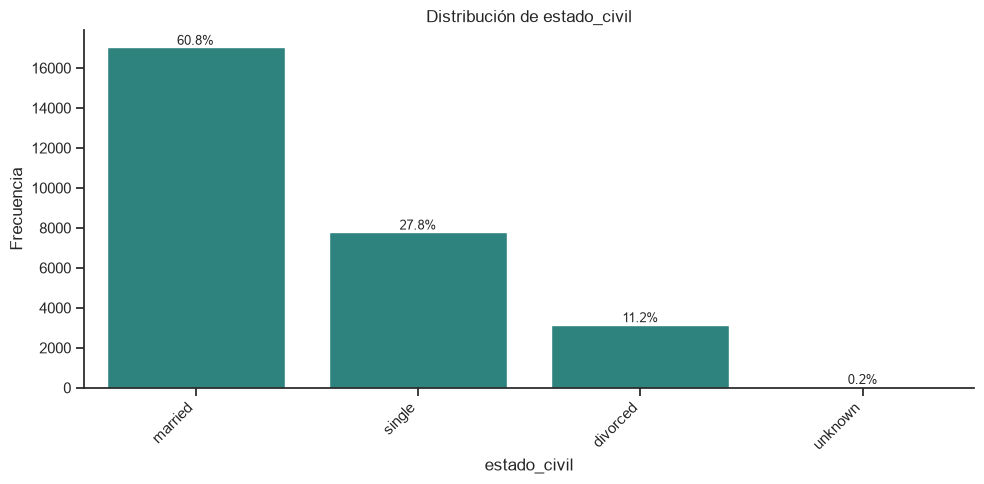

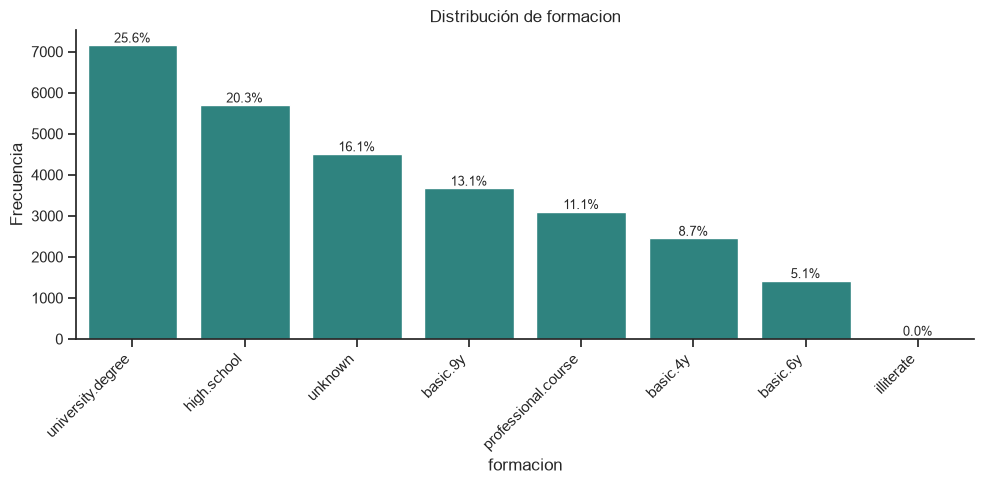

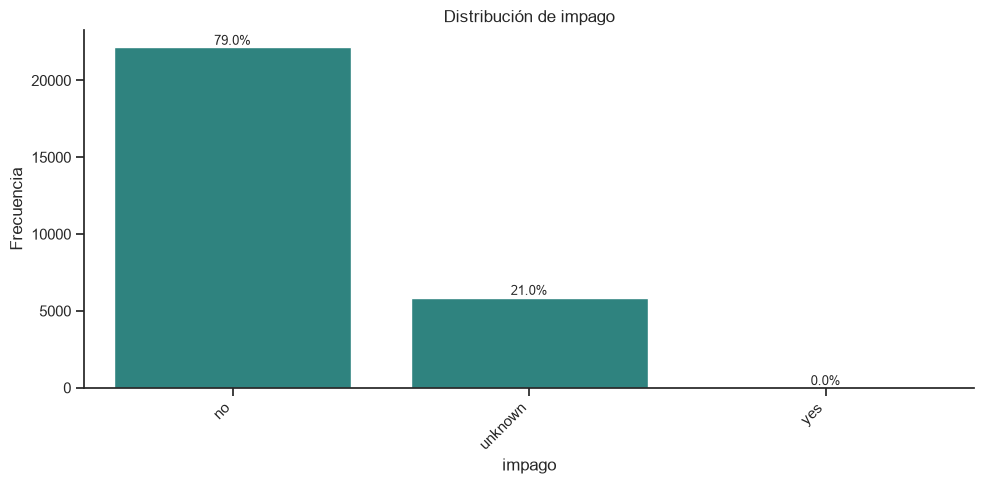

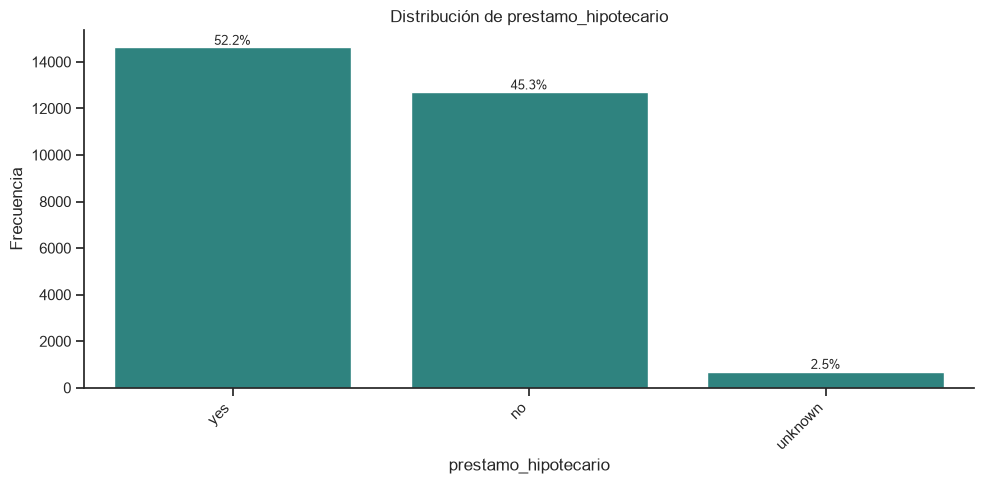

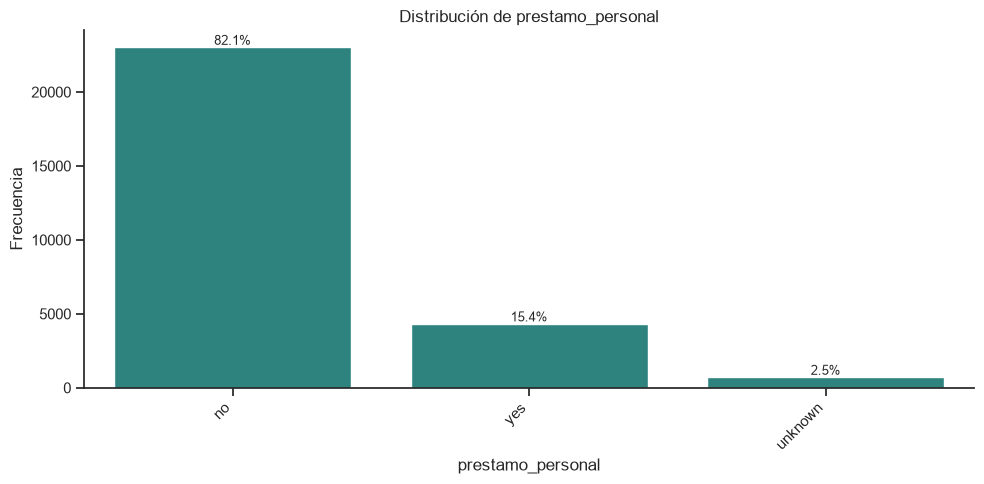

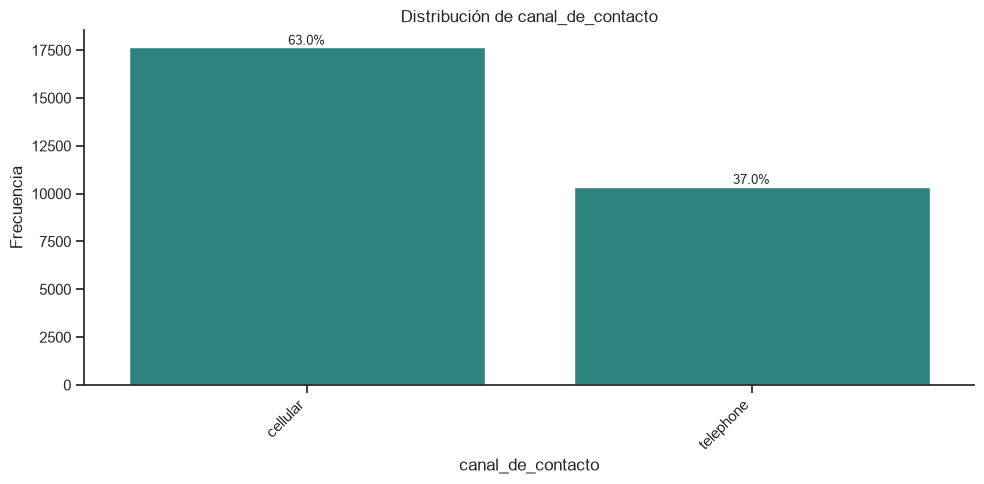

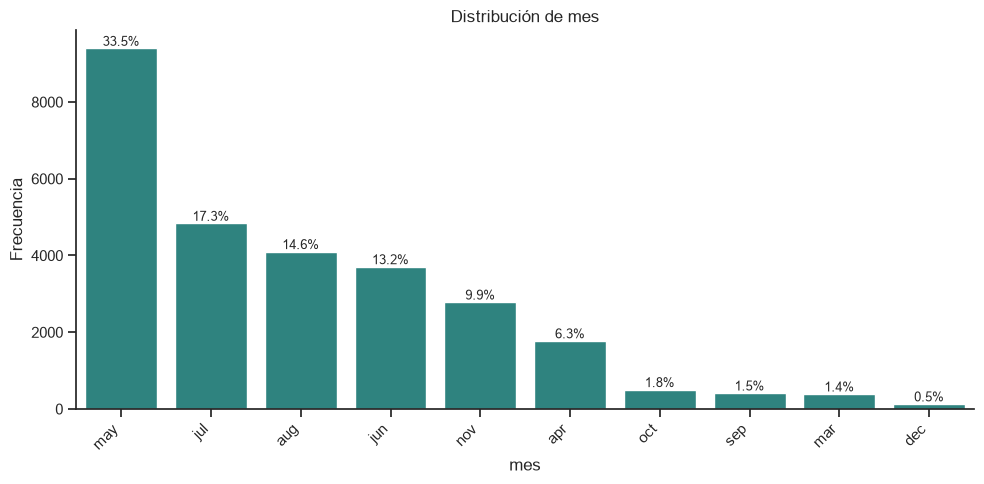

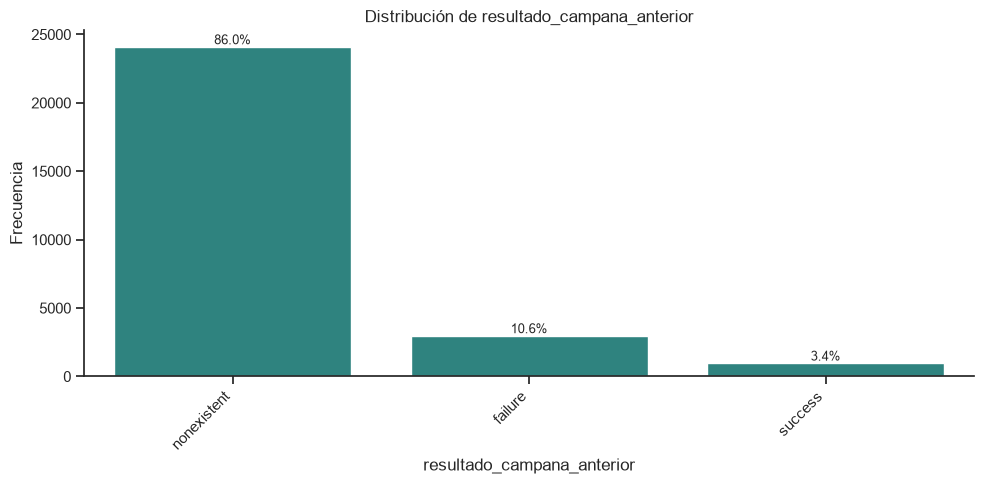

✅ Gráficos generados


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 5 — EDA categóricas y booleanas (análisis gráfico)
# ═══════════════════════════════════════════════════════════════════════

# ── Tema profesional seaborn (reaplicado por robustez) ────────────────
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

color_eda = sns.color_palette("viridis", 1)[0]

cat = tipos['categoricas']

# Límite de categorías a mostrar (params; None → todas)
max_cat_grafico = params['max_categorias_grafico']
if max_cat_grafico is not None:
    print(f'ℹ️ Aviso: se muestran solo las {max_cat_grafico} categorías más frecuentes por variable')

# ── Función: barras para categóricas (con % sobre total) ──────────────
def grafico_barras_categorica(df, col, max_cat=None):
    vc = df[col].value_counts(dropna=True).sort_values(ascending=False)
    if max_cat is not None:
        vc = vc.head(max_cat)
    total = vc.sum()
    pct = vc / total * 100

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=vc.index.astype(str), y=vc.values, color=color_eda)
    for i, (v, p) in enumerate(zip(vc.values, pct.values)):
        ax.text(i, v, f'{p:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ── Generación de gráficos (1 figura por variable) ─────────────────────
print('═' * 70)
print('CATEGÓRICAS / BOOLEANAS — GRÁFICOS DE BARRAS')
print('═' * 70)
for col in cat:
    grafico_barras_categorica(df, col, max_cat=max_cat_grafico)

print('✅ Gráficos generados')

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# TAREAS 6-9 — Alta cardinalidad, texto y fechas (verificación "no aplica")
# ═══════════════════════════════════════════════════════════════════════

# ── TAREA 6 — EDA alta cardinalidad (análisis estadístico) ────────────
print('═' * 70)
print('TAREA 6 — ALTA CARDINALIDAD (análisis estadístico)')
print('═' * 70)
ac = tipos['alta_cardinalidad']
print(f'Variables de alta cardinalidad (umbral > {umbral_ac}):',
      ac if ac else 'NINGUNA → no aplica')
print()

# Verificación de concentración de las variables categóricas por cardinalidad
print('• Verificación de concentración (top-5) de las categóricas con mayor cardinalidad:')
card_cat = df[tipos['categoricas']].nunique(dropna=True).sort_values(ascending=False)
for col in card_cat.index:
    vc = df[col].value_counts(dropna=True)
    top5 = vc.head(5)
    pct_top5 = top5.sum() / vc.sum() * 100
    es_ac = '⚠️ candidata a alta cardinalidad' if card_cat[col] > umbral_ac else 'OK (no alta cardinalidad)'
    print(f'  • {col}: cardinalidad={card_cat[col]}, top-5 cubre {pct_top5:.1f}%  → {es_ac}')

# ── TAREA 7 — EDA alta cardinalidad (análisis gráfico) ────────────────
print()
print('═' * 70)
print('TAREA 7 — ALTA CARDINALIDAD (análisis gráfico)')
print('═' * 70)
if ac:
    print('Generando top-20 de categorías...')
else:
    print('No aplica: no existen variables de alta cardinalidad (sin gráficos)')

# ── TAREA 8 — EDA texto (estadísticos y gráfico) ──────────────────────
print()
print('═' * 70)
print('TAREA 8 — TEXTO (estadísticos y gráfico)')
print('═' * 70)
texto = []
for col in df.columns:
    if df[col].dtype == object:
        texto.append(col)
print('Columnas de tipo object (candidatas a texto):',
      texto if texto else 'NINGUNA → no aplica (todas las no numéricas son "category")')

# ── TAREA 9 — EDA fechas (estadísticos y gráfico) ─────────────────────
print()
print('═' * 70)
print('TAREA 9 — FECHAS (estadísticos y gráfico)')
print('═' * 70)
fechas = []
for col in df.columns:
    if pd.api.types.is_datetime64_any_dtype(df[col].dtype):
        fechas.append(col)
print('Columnas de tipo fecha:',
      fechas if fechas else 'NINGUNA → no aplica')

══════════════════════════════════════════════════════════════════════
TAREA 6 — ALTA CARDINALIDAD (análisis estadístico)
══════════════════════════════════════════════════════════════════════
Variables de alta cardinalidad (umbral > 1400): NINGUNA → no aplica

• Verificación de concentración (top-5) de las categóricas con mayor cardinalidad:
  • trabajo: cardinalidad=12, top-5 cubre 80.4%  → OK (no alta cardinalidad)
  • mes: cardinalidad=10, top-5 cubre 88.6%  → OK (no alta cardinalidad)
  • formacion: cardinalidad=8, top-5 cubre 86.1%  → OK (no alta cardinalidad)
  • estado_civil: cardinalidad=4, top-5 cubre 100.0%  → OK (no alta cardinalidad)
  • impago: cardinalidad=3, top-5 cubre 100.0%  → OK (no alta cardinalidad)
  • prestamo_hipotecario: cardinalidad=3, top-5 cubre 100.0%  → OK (no alta cardinalidad)
  • prestamo_personal: cardinalidad=3, top-5 cubre 100.0%  → OK (no alta cardinalidad)
  • resultado_campana_anterior: cardinalidad=3, top-5 cubre 100.0%  → OK (no alta cardinalid

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 10 — Consolidación y cierre
# ═══════════════════════════════════════════════════════════════════════

# ── Guardado del dataframe resultante de EDA ──────────────────────────
# (sin transformaciones aplicadas durante el EDA → igual al tablón de calidad)
df.to_pickle(ENTRENAMIENTO / '03_train_tablon_eda.pkl')
print('✅ DataFrame guardado: 03_train_tablon_eda.pkl')
print()

# ── Estructura final para copilot-instructions.md ─────────────────────
print('── ESTRUCTURA FINAL DEL DATAFRAME (df.info()) ──')
df.info()

✅ DataFrame guardado: 03_train_tablon_eda.pkl

── ESTRUCTURA FINAL DEL DATAFRAME (df.info()) ──
<class 'pandas.DataFrame'>
RangeIndex: 28015 entries, 0 to 28014
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   edad                          28015 non-null  int64   
 1   trabajo                       28015 non-null  category
 2   estado_civil                  28015 non-null  category
 3   formacion                     28015 non-null  category
 4   impago                        28015 non-null  category
 5   prestamo_hipotecario          28015 non-null  category
 6   prestamo_personal             28015 non-null  category
 7   canal_de_contacto             28015 non-null  category
 8   mes                           28015 non-null  category
 9   num_contactos_esta_campana    28015 non-null  int64   
 10  num_dias_ultimo_contacto      28015 non-null  int64   
 11  num_contactos_otras_c